Multilayer Perceptron (MLP) sederhana menggunakan TensorFlow/Keras

Penjelasan Arsitektur

Input Layer (4 fitur)

        │
        ▼
Hidden Layer 1 (16 neuron, ReLU)

        │
        ▼
Hidden Layer 2 (8 neuron, ReLU)

        │
        ▼
Output Layer (3 neuron, Softmax)



Fungsi Aktivasi

- ReLU untuk hidden layer.

- Softmax untuk klasifikasi multikelas.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4250 - loss: 1.3336
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4250 - loss: 1.2171
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4333 - loss: 1.1249 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4417 - loss: 1.0340 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4250 - loss: 0.9565 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4333 - loss: 0.8812 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4833 - loss: 0.8087 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6500 - loss: 0.7386 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6833 - loss: 0.6817 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6346 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7083 - loss: 0.5972 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

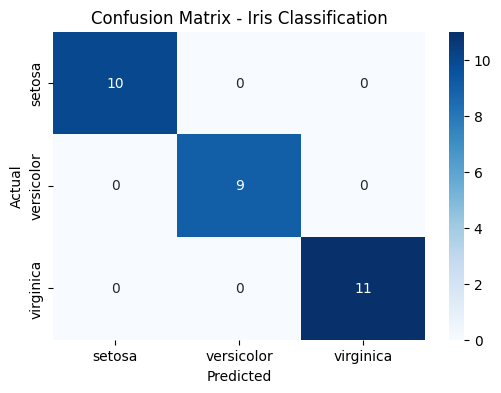

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================
# Load Dataset
# ======================
iris = load_iris()

X = iris.data
y = iris.target

# ======================
# Normalisasi
# ======================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One Hot Encoding
y_cat = tf.keras.utils.to_categorical(y)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42
)

# ======================
# MLP Model
# ======================
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ======================
# Training
# ======================
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=1
)

# ======================
# Evaluasi Accuracy
# ======================
loss, acc = model.evaluate(X_test, y_test)

print(f"\nAccuracy = {acc:.4f}")

# ======================
# Prediksi
# ======================
y_pred = model.predict(X_test)

# Ubah one-hot menjadi label
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)

# ======================
# Confusion Matrix
# ======================
cm = confusion_matrix(
    y_true_class,
    y_pred_class
)

print("\nConfusion Matrix:")
print(cm)

# ======================
# Classification Report
# ======================
print("\nClassification Report:")
print(classification_report(
    y_true_class,
    y_pred_class,
    target_names=iris.target_names
))

# ======================
# Visualisasi Confusion Matrix
# ======================
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Classification")

plt.show()

CONVOLUTIONAL NEURAL NETWORK

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9531 - loss: 0.1533 - val_accuracy: 0.9778 - val_loss: 0.0728
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9846 - loss: 0.0490 - val_accuracy: 0.9814 - val_loss: 0.0629
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9889 - val_loss: 0.0362
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9887 - val_loss: 0.0375
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9940 - loss: 0.0171 - val_accuracy: 0.9868 - val_loss: 0.0480
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9883 - loss: 0.0385

Accuracy : 0.9883000254631042
Loss     : 0.03847801312804222
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Confusion Matrix:
[[ 972    3    0    0    0    0    1    1    3    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   2    1 1023    1    1    0    0    3    1    0

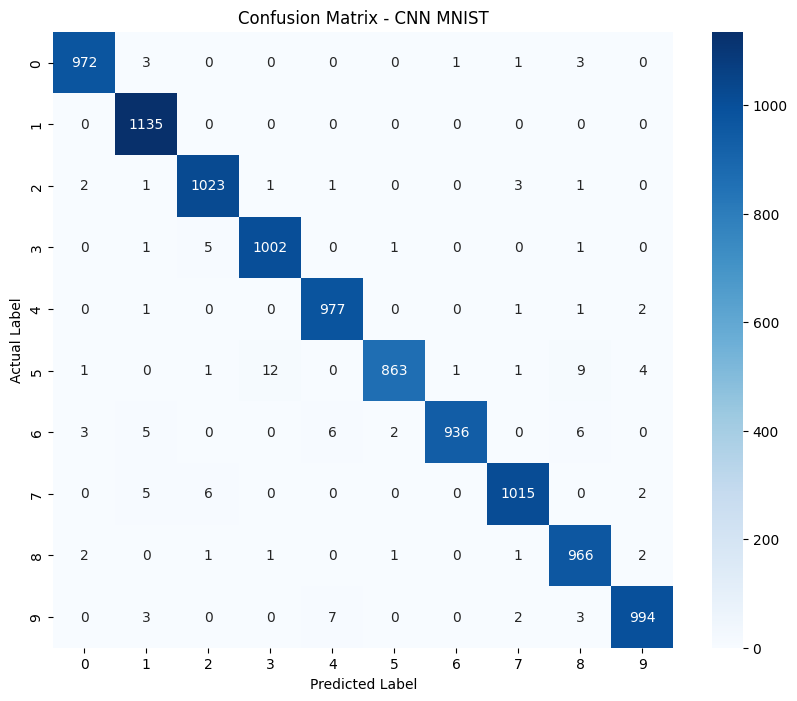

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# Load Dataset MNIST
# ==========================
(X_train, y_train), (X_test, y_test) = \
    tf.keras.datasets.mnist.load_data()

# ==========================
# Normalisasi
# ==========================
X_train = X_train / 255.0
X_test = X_test / 255.0

# Tambah Channel
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ==========================
# Model CNN
# ==========================
model = models.Sequential([
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        10,
        activation='softmax'
    )
])

# ==========================
# Compile
# ==========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Training
# ==========================
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

# ==========================
# Evaluasi
# ==========================
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print("\nAccuracy :", test_acc)
print("Loss     :", test_loss)

# ==========================
# Prediksi
# ==========================
y_pred_prob = model.predict(X_test)

# Ambil kelas dengan probabilitas tertinggi
y_pred = np.argmax(y_pred_prob, axis=1)

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# ==========================
# Classification Report
# ==========================
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================
# Visualisasi Confusion Matrix
# ==========================
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - CNN MNIST")

plt.show()

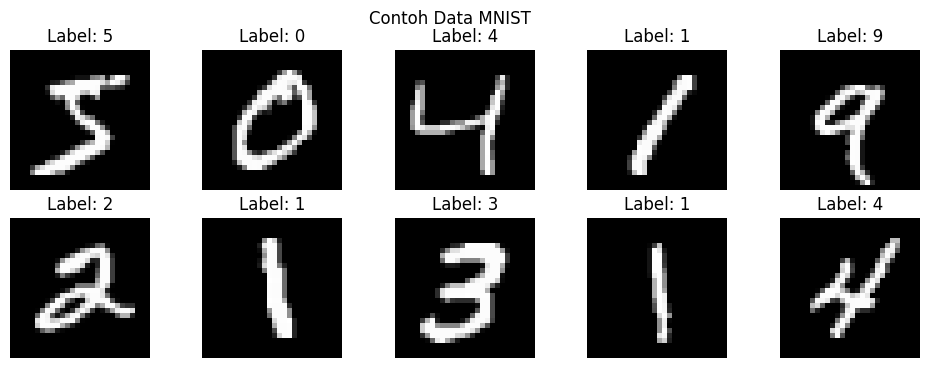

In [5]:
import matplotlib.pyplot as plt

# Tampilkan 10 gambar pertama
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.suptitle("Contoh Data MNIST")
plt.show()

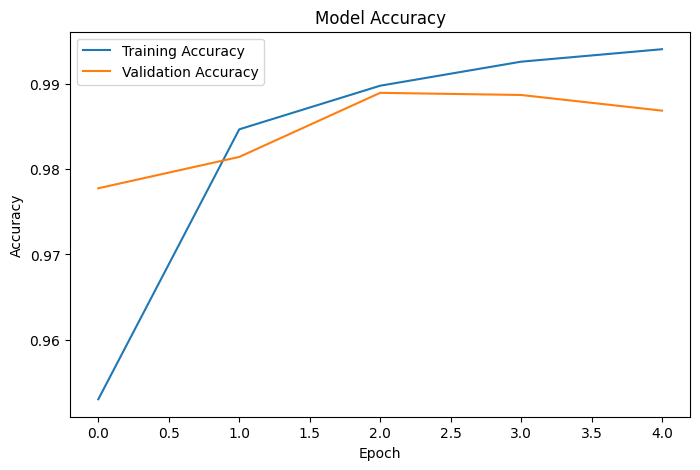

In [6]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

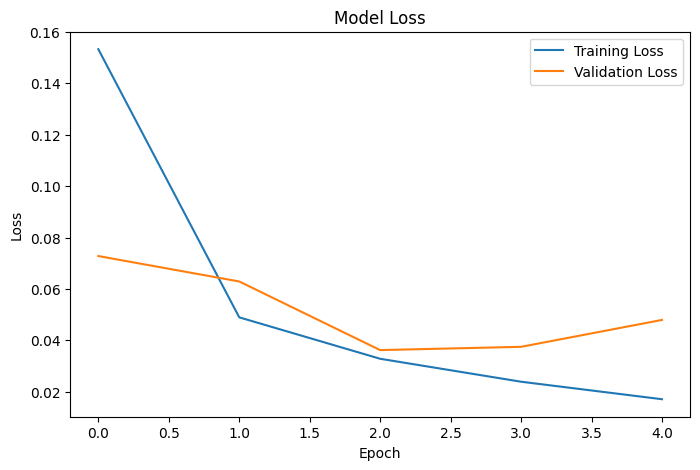

In [7]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

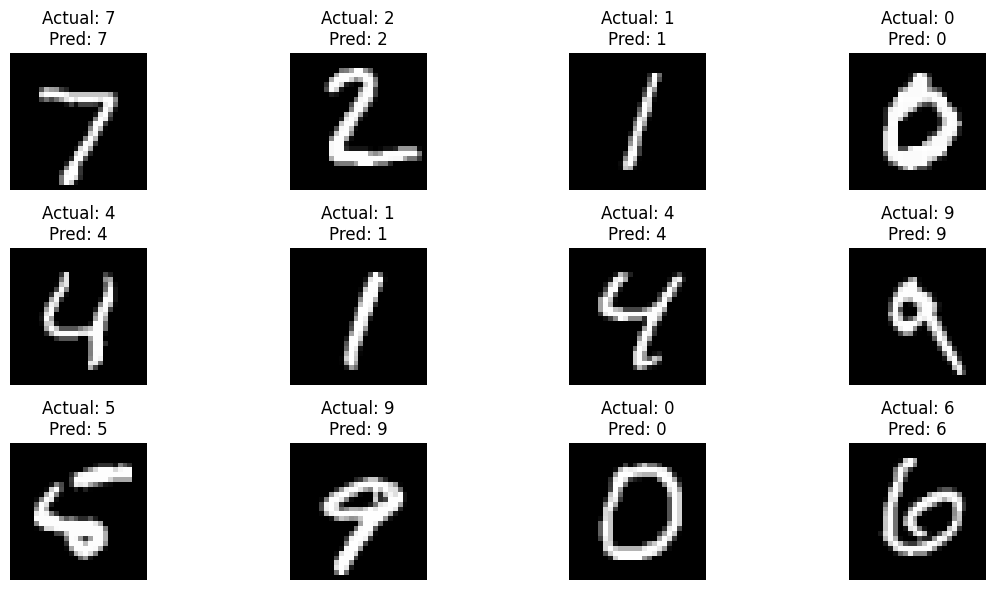

In [9]:
plt.figure(figsize=(12,6))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\nPred: {y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()